#### Multivariate Normal Distribution

**The Bivariate Gaussian Distribution**: The probability density function (pdf) of the bivariate Gaussian distribution is given by
- $f(x, y; \mu_x, \mu_y, \sigma_x^2, \sigma_y^2, \rho) = \frac{1}{2\pi\sigma_x\sigma_y\sqrt{1-\rho^2}} \exp\left[ -\frac{1}{2(1-\rho^2)} \left( \frac{(x-\mu_x)^2}{\sigma_x^2} + \frac{(y-\mu_y)^2}{\sigma_y^2} - \frac{2\rho(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y} \right) \right]$

**The Multivariate Gaussian Distribution**: For a general $d$-dimensional multivariate Gaussian distribution with mean vector $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$, the pdf is defined as
- $f(\mathbf{x}; \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{d/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left[ -\frac{1}{2} (\mathbf{x}-\boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu}) \right]$

**Marginal Distributions and Covariance**: The marginal distributions of $X$ and $Y$ are univariate Gaussians
- $X \sim {N}(\mu_x, \sigma_x^2)$, and $Y \sim {N}(\mu_y, \sigma_y^2)$.

Covariance: The covariance between $X$ and $Y$ is expressed in terms of the correlation coefficient
- $\rho$ $\text{Cov}(X, Y) = \rho\sigma_x\sigma_y$

**Alternative Representation**: We can represent $X$ and $Y$ using two independent standard normal random variables, $Z_1, Z_2 \sim {N}(0, 1)$
- $X = \sigma_x Z_1 + \mu_x$, $\quad$ $Y = \sigma_y(\rho Z_1 + \sqrt{1 - \rho^2} Z_2) + \mu_y$

Note that for $d=2$, the general multivariate pdf simplifies exactly to the bivariate pdf provided at the beginning, assuming the covariance matrix is defined as $\boldsymbol{\Sigma} = \begin{pmatrix} \sigma_x^2 & \rho\sigma_x\sigma_y \\ \rho\sigma_x\sigma_y & \sigma_y^2 \end{pmatrix}$.


#### MLE for Multivariate Normal Distribution

The MLE is a method of estimating the parameters of a statistical model given observations, by finding the parameter values that maximize the likelihood function. The likelihood function is the probability of observing the given data as a function of the parameters.

#### MLE for Multivariate Normal Distribution

For a **Multivariate Normal Distribution**, denoted as $N(\boldsymbol{\mu}, \mathbf{\Sigma})$, the parameters to be estimated are the mean vector $\boldsymbol{\mu}$ and the covariance matrix $\mathbf{\Sigma}$. Given a set of $N$ independent and identically distributed (i.i.d.) observations $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_N$, each being a $d$-dimensional random vector, the probability density function (PDF) for a single observation $\mathbf{x}$ is
- $f(\mathbf{x}; \boldsymbol{\mu}, \mathbf{\Sigma}) = \frac{1}{\sqrt{(2\pi)^d |\mathbf{\Sigma}|}} \exp\left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)$

The likelihood function for $N$ observations is the product of their individual PDFs
- $L(\boldsymbol{\mu}, \mathbf{\Sigma} | \mathbf{x}_1, \ldots, \mathbf{x}_N) = \prod_{i=1}^N \frac{1}{\sqrt{(2\pi)^d |\mathbf{\Sigma}|}} \exp\left( -\frac{1}{2} (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) \right)$

It is often easier to work with the **log-likelihood function**:
- $\ell(\boldsymbol{\mu}, \mathbf{\Sigma}) = \log L(\boldsymbol{\mu}, \mathbf{\Sigma}) = -\frac{Nd}{2} \log(2\pi) - \frac{N}{2} \log|\mathbf{\Sigma}| - \frac{1}{2} \sum_{i=1}^N (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})$

To find the MLEs of $\boldsymbol{\mu}$ and $\mathbf{\Sigma}$, we take the partial derivatives of the log-likelihood function with respect to each parameter and set them to zero.

#### MLE for the Mean Vector ($\boldsymbol{\mu}$)

Setting $\frac{\partial \ell}{\partial \boldsymbol{\mu}} = 0$ yields the MLE for the mean vector $\hat{\boldsymbol{\mu}} = \frac{1}{N} \sum_{i=1}^N \mathbf{x}_i$. This is simply the sample mean of the observed data.

#### MLE for the Covariance Matrix ($\mathbf{\Sigma}$)

Setting $\frac{\partial \ell}{\partial \mathbf{\Sigma}} = 0$ yields the MLE for the covariance matrix $\hat{\mathbf{\Sigma}} = \frac{1}{N} \sum_{i=1}^N (\mathbf{x}_i - \hat{\boldsymbol{\mu}}) (\mathbf{x}_i - \hat{\boldsymbol{\mu}})^T$

This is the sample covariance matrix, denoted as $\mathbf{S}$, but without the $(N-1)$ normalization factor. Note that this is a biased estimator for the covariance matrix, whereas using $(N-1)$ in the denominator (for the unbiased sample covariance) is more common in practice. We demontrate this with code in Python.

In [ ]:
import numpy as np

# Generate synthetic data from a multivariate normal distribution
# For simplicity, use a 2-dimensional distribution.
# True mean vector
true_mu = np.array([1, 2])

# True covariance matrix
true_sigma = np.array([
    [0.5, 0.2],
    [0.2, 0.8] ])

# Number of samples
N = 1000

# Generate data
X = np.random.multivariate_normal(true_mu, true_sigma, N)

print("True Mean (mu):", true_mu)
print("True Covariance (Sigma):\n", true_sigma)
print("\nGenerated data shape:", X.shape)

True Mean (mu): [1 2]
True Covariance (Sigma):
 [[0.5 0.2]
 [0.2 0.8]]

Generated data shape: (1000, 2)


The Estimated Mean and Covariance from the MLE are very close to the True Mean and Covariance used to generate the data, especially with a large number of samples ($N=1000$).

It's important to remember that $np.cov$ with $bias=True$ calculates the MLE of the covariance matrix. If $bias=False$ (default), it calculates the unbiased sample covariance matrix using $N-1$ in the denominator.

#### Plot Likelihood and Log-Likelihood

Plot for a 1D normal distribution with a fixed variance and varying mean, to see how these functions are maximized with respect to the mean parameter given some observed data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define a set of observed 1D data points.
# Chosen true mean and standard deviation for data generation
true_mean_1d = 5.0
true_std_1d = 1.5
N_1d = 100 # Number of samples

# Generate 1D data
np.random.seed(42) # for reproducibility
data_1d = np.random.normal(loc=true_mean_1d, scale=true_std_1d, size=N_1d)

print(f"Generated 1D data shape: {data_1d.shape} \n"
      f"True Mean (1D): {true_mean_1d} \n"
      f"True Std Dev (1D): {true_std_1d} \n"
      f"Sample Mean (1D): {np.mean(data_1d):.2f} \n"
      f"Sample Std Dev (1D): {np.std(data_1d):.2f}")

# Define a fixed standard deviation for likelihood calculation.
# Assume the standard deviation is known for the purpose of maximizing the mean.
f_std = true_std_1d # Fixed standard deviation, close to true_std_1d

# Create an array of possible mean values
# This range should span values around your true mean.
candidate_means = np.linspace(true_mean_1d - 3 * f_std, true_mean_1d + 3 * f_std, 200)

print(f"\nFixed Standard Deviation for Likelihood: {f_std} \n"
      f"Number of candidate means: {len(candidate_means)}")

Generated 1D data shape: (100,) 
True Mean (1D): 5.0 
True Std Dev (1D): 1.5 
Sample Mean (1D): 4.84 
Sample Std Dev (1D): 1.36

Fixed Standard Deviation for Likelihood: 1.5 
Number of candidate means: 200


In [ ]:
from scipy.stats import norm # Already imported, but good for context

# Implement a function to calculate the PDF
def normal_pdf(x, mu, sigma):
    return norm.pdf(x, loc=mu, scale=sigma)

# Implement a function for the likelihood (product of PDFs)
def calculate_likelihood(data, candidate_mu, fixed_std):
    # Calculate PDF for each data point given the candidate mean and fixed std
    pdfs = normal_pdf(data, candidate_mu, fixed_std)
    # The likelihood is the product of these PDFs
    # To avoid numerical underflow, we often work with log-likelihood.
    # However, for visualization, we'll calculate the actual likelihood here.
    # Handle cases where pdfs might be zero, although norm.pdf should return very small positive values.
    # Multiplying many small numbers can lead to zero, so for better visualization, we will use log-likelihood for actual calculations and then exponentiate for likelihood.
    # Or, as typically done, calculate the sum of log-pdfs and then exponentiate it.
    # Here we'll stick to direct product for demonstration, but be aware of limitations.
    likelihood = np.prod(pdfs)
    return likelihood

# Implement a function for the log-likelihood (sum of log PDFs)
def calculate_log_likelihood(data, candidate_mu, fixed_std):
    # Calculate the log PDF for each data point
    log_pdfs = norm.logpdf(data, loc=candidate_mu, scale=fixed_std)
    # The log-likelihood is the sum of these log PDFs
    log_likelihood = np.sum(log_pdfs)
    return log_likelihood

# Calculate the likelihood and log-likelihood for each candidate mean value
likelihoods = [calculate_likelihood(data_1d, mu, f_std) for mu in candidate_means]
log_likelihoods = [calculate_log_likelihood(data_1d, mu, f_std) for mu in candidate_means]

# Convert to numpy arrays for easier plotting
likelihoods = np.array(likelihoods)
log_likelihoods = np.array(log_likelihoods)

print(f"Calculated {len(likelihoods)} likelihood values. \n"
f"Calculated {len(log_likelihoods)} log-likelihood values.")

Calculated 200 likelihood values. 
Calculated 200 log-likelihood values.


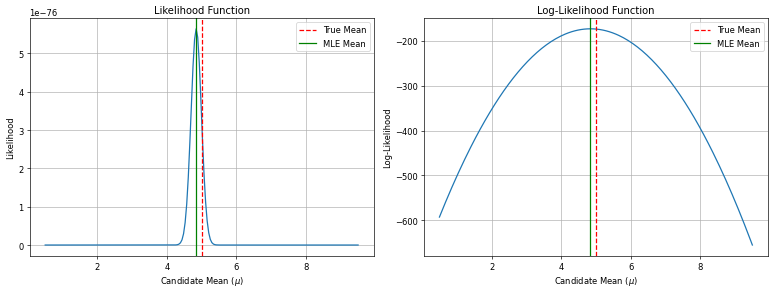


True Mean: 5.0 
Estimated MLE Mean (Sample Mean): 4.84
Candidate Mean that maximizes Likelihood: 4.84 
Candidate Mean that maximizes Log-Likelihood: 4.84


In [ ]:
import matplotlib.pyplot as plt

# Calculate the sample mean (MLE for mu when sigma is known)
estimated_mu_mle_1d = np.mean(data_1d)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=60)

# Plot Likelihood Function
axes[0].plot(candidate_means, likelihoods)
axes[0].set_title('Likelihood Function')
axes[0].set_xlabel('Candidate Mean ($\\mu$)')
axes[0].set_ylabel('Likelihood')
axes[0].axvline(x=true_mean_1d, color='r', linestyle='--', label='True Mean')
axes[0].axvline(x=estimated_mu_mle_1d, color='g', linestyle='-', label='MLE Mean')
axes[0].legend() ; axes[0].grid(True)

# Plot Log-Likelihood Function
axes[1].plot(candidate_means, log_likelihoods)
axes[1].set_title('Log-Likelihood Function')
axes[1].set_xlabel('Candidate Mean ($\\mu$)')
axes[1].set_ylabel('Log-Likelihood')
axes[1].axvline(x=true_mean_1d, color='r', linestyle='--', label='True Mean')
axes[1].axvline(x=estimated_mu_mle_1d, color='g', linestyle='-', label='MLE Mean')
axes[1].legend() ; axes[1].grid(True)
plt.tight_layout() ; plt.show()

print(f"\nTrue Mean: {true_mean_1d} \n"
f"Estimated MLE Mean (Sample Mean): {estimated_mu_mle_1d:.2f}")

# Find the candidate mean that maximizes the likelihood (and log-likelihood)
max_likelihood_mu_index = np.argmax(likelihoods)
max_likelihood_mu = candidate_means[max_likelihood_mu_index]

print(f"Candidate Mean that maximizes Likelihood: {max_likelihood_mu:.2f} \n"
f"Candidate Mean that maximizes Log-Likelihood: {max_likelihood_mu:.2f}")

#### Distribution of Sample Mean (mu_hat_MLE)

Perform Monte Carlo simulations by repeatedly generating data from a multivariate normal distribution and calculating the MLE of the mean (mu_hat_MLE) for each simulation. Then, plot the distribution of these estimated means.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the number of simulations and sample size
num_simulations = 1000 # n-of times to repeat the data generation and estimation
N_sim_samples = 100 # Sample size for each simulation (can be adjusted)

# Reuse previously defined true_mu and true_sigma
# true_mu = np.array([1, 2]) ; true_sigma = np.array([[0.5, 0.2],[0.2, 0.8]])

# Ensure true_mu and true_sigma are from above, else define them for robustness
if 'true_mu' not in globals():
    true_mu = np.array([1, 2])
if 'true_sigma' not in globals():
    true_sigma = np.array([[0.5, 0.2], [0.2, 0.8] ])

# Dimensionality of the data
p_dim = len(true_mu)

# Initialize an empty list to store the estimated means from each simulation
estimated_means_mle = []

# Loop through the specified number of simulations
for _ in range(num_simulations):
    # a. Generate N_sim_samples new data points from a multivariate normal
    simulated_data = np.random.multivariate_normal(true_mu, true_sigma, N_sim_samples)
    # b. Calculate the MLE of the mean vector (which is simply the sample mean)
    mu_hat_mle = np.mean(simulated_data, axis=0)
    # c. Append this estimated mean vector to the list
    estimated_means_mle.append(mu_hat_mle)

# Convert the list of estimated means into a NumPy array
estimated_means_mle = np.array(estimated_means_mle)

print(f"Number of simulations: {num_simulations} \n"
f"Sample size per simulation: {N_sim_samples} \n"
f"Shape of estimated means array: {estimated_means_mle.shape}")

Number of simulations: 1000 
Sample size per simulation: 100 
Shape of estimated means array: (1000, 2)


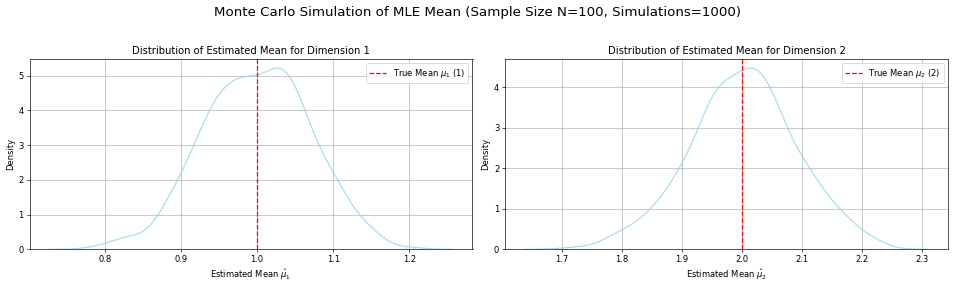

Visualization of the distribution of estimated means completed.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure with subplots (one for each dimension of the mean vector).
fig, axes = plt.subplots(1, p_dim, figsize=(8 * p_dim, 5), dpi=60)

# Ensure axes is an array even if p_dim is 1
if p_dim == 1:
    axes = [axes]

# For each dimension, plot a KDE of the estimated means
for i in range(p_dim):
    sns.kdeplot(estimated_means_mle[:, i], ax=axes[i], fill=False, color='skyblue', alpha=0.7)

    # Add a vertical line for the true mean of that dimension.
    axes[i].axvline(x=true_mu[i], color='red', linestyle='--', label=rf'True Mean $\mu_{i+1}$ ({true_mu[i]})')

    # Add appropriate titles, x-labels, and y-labels to each subplot
    axes[i].set_title(f'Distribution of Estimated Mean for Dimension {i+1}')
    axes[i].set_xlabel(rf'Estimated Mean $\hat{{\mu}}_{i+1}$ ')
    axes[i].set_ylabel('Density')
    axes[i].legend() ; axes[i].grid(True)

fig.suptitle(f'Monte Carlo Simulation of MLE Mean (Sample Size N={N_sim_samples}, Simulations={num_simulations})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

print("Visualization of the distribution of estimated means completed.")

#### Asymptotic Variance of mu_hat_MLE
Theoretical explanation of the asymptotic variance of the MLE for the mean vector (mu_hat_MLE) of a multivariate normal distribution.


#### Asymptotic Variance of $\hat{\boldsymbol{\mu}}_{MLE}$ for Multivariate Normal Distribution

For a multivariate normal distribution, $N(\boldsymbol{\mu}, \mathbf{\Sigma})$, the MLE of the mean vector $\boldsymbol{\mu}$ is the sample mean, given by
- $\hat{\boldsymbol{\mu}} = \frac{1}{N} \sum_{i=1}^N \mathbf{x}_i$ where $\mathbf{x}_i$ are i.i.d. observations from the distribution, and $N$ is the number of observations.

#### Asymptotic Distribution of the MLE

The theory of MLE states that, under certain regularity conditions, the MLE is asymptotically normally distributed. For the mean vector of a multivariate normal distribution, the asymptotic distribution of the MLE is
- $\sqrt{N}(\hat{\boldsymbol{\mu}} - \boldsymbol{\mu}) \sim N(\mathbf{0}, \mathbf{\Sigma})$

This means that as the number of samples $N$ approaches infinity, the scaled difference between the estimated mean and the true mean converges in distribution to a multivariate normal distribution with a zero mean vector and a covariance matrix equal to the true covariance matrix $\mathbf{\Sigma}$ of the data.

#### Asymptotic Variance-Covariance Matrix of $\hat{\boldsymbol{\mu}}$

From the asymptotic distribution given above, we can deduce the asymptotic variance-covariance matrix of $\hat{\boldsymbol{\mu}}$.

Given that $\sqrt{N}(\hat{\boldsymbol{\mu}} - \boldsymbol{\mu})$ has a covariance matrix of $\mathbf{\Sigma}$, we can find the covariance matrix of $(\hat{\boldsymbol{\mu}} - \boldsymbol{\mu})$ by dividing by $N$: $\text{Cov}(\hat{\boldsymbol{\mu}} - \boldsymbol{\mu}) = \frac{1}{N} \mathbf{\Sigma}$

Since $\boldsymbol{\mu}$ is a constant vector, $\text{Cov}(\hat{\boldsymbol{\mu}} - \boldsymbol{\mu}) = \text{Cov}(\hat{\boldsymbol{\mu}})$. Therefore, the asymptotic variance-covariance matrix of the MLE for the mean vector is $\text{Var}(\hat{\boldsymbol{\mu}}) = \frac{1}{N} \mathbf{\Sigma}$.

#### Implications

This result has several important implications:

**Consistency**: As $N \to \infty$, the variance $\frac{1}{N} \mathbf{\Sigma}$ approaches a zero matrix. This means that the estimator $\hat{\boldsymbol{\mu}}$ converges in probability to the true mean $\boldsymbol{\mu}$, making it a consistent estimator.

**Efficiency**: The MLE is known to be asymptotically efficient, meaning that it achieves the Cramér-Rao Lower Bound (CRLB) asymptotically. The CRLB provides a lower bound on the variance of any unbiased estimator. In this case, $\frac{1}{N} \mathbf{\Sigma}$ is indeed the CRLB for the mean vector of a multivariate normal distribution, indicating that the MLE for the mean is the most efficient unbiased estimator in large samples.

#### Compare Empirical and Theoretical Asymptotic Variance for mu_hat_MLE

Calculate the empirical variance of mu_hat_MLE from the simulation results and compare it to the theoretical asymptotic variance derived previously.


In [ ]:
# Calculate the empirical covariance matrix of estimated_means_mle
# estimated_means_mle has shape (num_simulations, p_dim)
# where rows are observations (simulations) and columns are variables (dimensions of mu)
# So, set rowvar=False
empirical_cov_mle = np.cov(estimated_means_mle, rowvar=False)

# Calculate the theoretical asymptotic covariance matrix
# The formula is (1/N) * Sigma, N is N_sim_samples, Sigma is true_sigma
theoretical_cov_mle = (1 / N_sim_samples) * true_sigma

# Print both the empirical and theoretical covariance matrices
print("Empirical Covariance Matrix of estimated_means_mle (from simulations):")
print(empirical_cov_mle)
print("\nTheoretical Asymptotic Covariance Matrix of mu_hat_MLE:")
print(theoretical_cov_mle)

# Optionally, calculate the difference or relative error
difference_cov = empirical_cov_mle - theoretical_cov_mle
print("\nDifference (Empirical - Theoretical):")
print(difference_cov)

# Common way to quantify difference is using a matrix norm, e.g. Frobenius norm
frobenius_norm_difference = np.linalg.norm(difference_cov, 'fro')
print(f"\nFrobenius Norm of the Difference: {frobenius_norm_difference:.4f}")

# Relative error (element-wise might be too noisy, norm is better)
# Let's consider a relative error based on the norm
# Avoid division by zero if theoretical_cov_mle contains zeros, though for covariance it shouldn't
if np.linalg.norm(theoretical_cov_mle, 'fro') > 1e-9:
    relative_error = frobenius_norm_difference / np.linalg.norm(theoretical_cov_mle, 'fro')
    print(f"Relative Error (Frobenius Norm): {relative_error:.4f}")
else:
    print("Cannot calculate relative error (theoretical norm is close to zero)")

Empirical Covariance Matrix of estimated_means_mle (from simulations):
[[0.00483242 0.00201783]
 [0.00201783 0.00769209]]

Theoretical Asymptotic Covariance Matrix of mu_hat_MLE:
[[0.005 0.002]
 [0.002 0.008]]

Difference (Empirical - Theoretical):
[[-1.67581860e-04  1.78322769e-05]
 [ 1.78322769e-05 -3.07914251e-04]]

Frobenius Norm of the Difference: 0.0004
Relative Error (Frobenius Norm): 0.0357


#### Asymptotic Variance for Norm of $\hat{\boldsymbol{\mu}}_{MLE}$

#### Theoretical Explanation for the Asymptotic Variance of $||\hat{\boldsymbol{\mu}}_{MLE}||^2$

To find the asymptotic variance of the squared norm of the Maximum Likelihood Estimator for the mean vector, $||\hat{\boldsymbol{\mu}}||^2$, we will utilize the Delta Method.

1.  For a multivariate normal distribution $N(\boldsymbol{\mu}, \mathbf{\Sigma})$, the **MLE of the mean vector** $\boldsymbol{\mu}$ is the sample mean: $\hat{\boldsymbol{\mu}} = \frac{1}{N} \sum_{i=1}^N \mathbf{x}_i$

2.  **The Squared Norm of the MLE Mean Vector**:
    $||\hat{\boldsymbol{\mu}}||^2 = \hat{\boldsymbol{\mu}}^T \hat{\boldsymbol{\mu}}$

3.  **Explain the Asymptotic Distribution of $\hat{\boldsymbol{\mu}}$**:From the properties of MLEs and the CLT, for a large number of samples $N$, the MLE $\hat{\boldsymbol{\mu}}$ is asymptotically normally distributed around the true mean $\boldsymbol{\mu}$ with a covariance matrix of $\frac{1}{N}\mathbf{\Sigma}$: $\hat{\boldsymbol{\mu}} \sim N(\boldsymbol{\mu}, \frac{1}{N}\mathbf{\Sigma})$

4.  **The Delta Method** is a statistical tool used to approximate the sampling distribution of a function of an asymptotically normal estimator. If we have an estimator $\hat{\boldsymbol{\theta}}$ that is asymptotically normal, i.e., $\sqrt{N}(\hat{\boldsymbol{\theta}} - \boldsymbol{\theta}) \to N(\mathbf{0}, \mathbf{C})$, and $g$ is a continuously differentiable function, then $g(\hat{\boldsymbol{\theta}})$ is also asymptotically normal, and its asymptotic variance can be approximated.

5.  **Apply the Delta Method**:

    a.  **Define the function $g(\mathbf{v})$**: We are interested in the variance of $||\hat{\boldsymbol{\mu}}||^2$, which is a function of $\hat{\boldsymbol{\mu}}$. So, let $g(\mathbf{v}) = \mathbf{v}^T \mathbf{v}$.

    b.  **Calculate the gradient of $g(\mathbf{v})$**: The gradient of $g(\mathbf{v})$ with respect to $\mathbf{v}$ is $\nabla g(\mathbf{v}) = \frac{\partial}{\partial \mathbf{v}} (\mathbf{v}^T \mathbf{v}) = 2\mathbf{v}$. When evaluated at the true mean $\boldsymbol{\mu}$, this becomes $\nabla g(\boldsymbol{\mu}) = 2\boldsymbol{\mu}$.

    c.  **State the formula for the asymptotic variance of $g(\hat{\boldsymbol{\mu}})$ using the Delta Method**: The asymptotic variance of $g(\hat{\boldsymbol{\mu}})$ is given by $\text{Var}(g(\hat{\boldsymbol{\mu}})) \approx (\nabla g(\boldsymbol{\mu}))^T \text{Var}(\hat{\boldsymbol{\mu}}) (\nabla g(\boldsymbol{\mu}))$

6.  **Substitute and Simplify to Derive the Asymptotic Variance of $||\hat{\boldsymbol{\mu}}||^2$**:
    Substitute $\nabla g(\boldsymbol{\mu}) = 2\boldsymbol{\mu}$ and $\text{Var}(\hat{\boldsymbol{\mu}}) = \frac{1}{N}\mathbf{\Sigma}$ into the Delta Method formula:
    $\text{Var}(||\hat{\boldsymbol{\mu}}||^2) \approx (2\boldsymbol{\mu})^T \left(\frac{1}{N}\mathbf{\Sigma}\right) (2\boldsymbol{\mu})$
    $\text{Var}(||\hat{\boldsymbol{\mu}}||^2) \approx 4\boldsymbol{\mu}^T \left(\frac{1}{N}\mathbf{\Sigma}\right) \boldsymbol{\mu}$
    $\text{Var}(||\hat{\boldsymbol{\mu}}||^2) \approx \frac{4}{N} \boldsymbol{\mu}^T \mathbf{\Sigma} \boldsymbol{\mu}$

This formula shows how the asymptotic variance of the squared norm of the estimated mean vector depends on the true mean vector $\boldsymbol{\mu}$, the true covariance matrix $\mathbf{\Sigma}$, and the number of observations $N$.

#### Plot Empirical and Theoretical Covariance Matrices

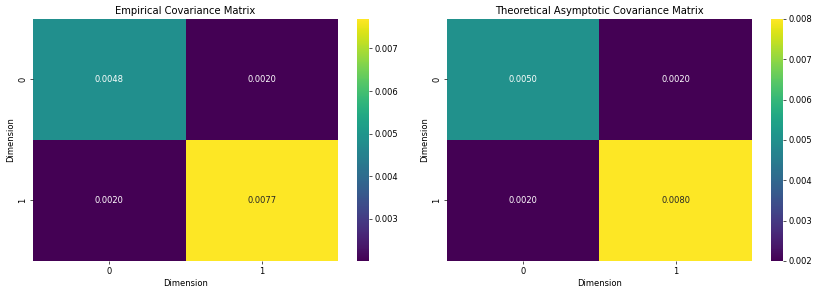

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=60)

sns.heatmap(empirical_cov_mle, annot=True, fmt=".4f", cmap="viridis", cbar=True, ax=axes[0])
axes[0].set_title('Empirical Covariance Matrix')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Dimension')
sns.heatmap(theoretical_cov_mle, annot=True, fmt=".4f", cmap="viridis", cbar=True, ax=axes[1])
axes[1].set_title('Theoretical Asymptotic Covariance Matrix')
axes[1].set_xlabel('Dimension') ; axes[1].set_ylabel('Dimension')
plt.tight_layout() ; plt.show()

The heatmaps visually confirm the close resemblance between the empirical and theoretical covariance matrices. The values in corresponding positions are very similar, with only minor differences, which is expected given the large number of simulations and samples used.

#### Comparison of Estimated MLEs with True Parameters

In [ ]:
import numpy as np

# Calculate the MLE for the mean and covariance from the initially generated data (X)
estimated_mu_mle = np.mean(X, axis=0)
estimated_sigma_mle = np.cov(X, rowvar=False, bias=True)

print("True Mean (mu):", true_mu)
print("Estimated Mean (MLE):", estimated_mu_mle)
print("\nTrue Covariance (Sigma):\n", true_sigma)
print("Estimated Covariance (MLE):\n", estimated_sigma_mle)

# Calculate and print the absolute difference for a quick comparison
mean_difference = np.abs(true_mu - estimated_mu_mle)
covariance_difference = np.abs(true_sigma - estimated_sigma_mle)

print("\nAbsolute Difference in Mean Estimates:", mean_difference)
print("Absolute Difference in Covariance Estimates:\n", covariance_difference)

True Mean (mu): [1 2]
Estimated Mean (MLE): [0.9558239  1.96405163]

True Covariance (Sigma):
 [[0.5 0.2]
 [0.2 0.8]]
Estimated Covariance (MLE):
 [[0.50596728 0.22250408]
 [0.22250408 0.84136365]]

Absolute Difference in Mean Estimates: [0.0441761  0.03594837]
Absolute Difference in Covariance Estimates:
 [[0.00596728 0.02250408]
 [0.02250408 0.04136365]]
